In [1]:
import pyradtran
from pyradtran import Var
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar_spectral.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')

In [4]:
# Arctic stratus parameter space (libRadtran units)
cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.array([10, 50, 100, 150])
lwcs = lwps / 700  # convert to kg m^-3 to fill the 700 m layer uniformly
reffs = [15]           

cbh = [0.3] * len(lwcs)
cth = [1] * len(lwcs)

times = pd.date_range("2024-03-01 12:00", periods=5, freq="7d")
lats = np.linspace(80, 60, 5) # this is a trick to sample through a high number of SZA... vary lat and time together...
print(lats)
lon = [0] * len(times)
altitudes = [0]
surface_temperatures = [255] * len(times)

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("time",), surface_temperatures),
        #"albedo_sw": (("albedo",), albedos_sw),
        #"albedo_lw": (("albedo",), albedos_lw),
    }
)

ds_ = ds.drop_vars(["lwc", "reff", "cth", "cbh"])

ds_sim_no_cloud_solar = ds_.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar_spectral.yaml',
    #    save_to_file=True, 
    return_dataset=True,
    show_progress=True,
    params={
        'sur_temperature': Var('surface_temperature'),
        'albedo': Var('albedo_sw'),
        'albedo_library IGBP' : '',
        'brdf_rpv_type' : '19'
    }
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar_spectral.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    save_to_file=True, 
    return_dataset=True,
    show_progress=True,
    params={
        'sur_temperature': Var('surface_temperature'),
        'albedo_library IGBP' : '',
        'brdf_rpv_type' : '19'
    }
)



[80. 75. 70. 65. 60.]


Running simulations: 100%|██████████| 20/20 [01:25<00:00,  4.28s/sim, Success=20, Total=20]


In [5]:
ds_sim_cloudy_solar['lwc'] = ('lwc', lwps)


In [6]:
ds_sim_no_cloud_solar['albedo_sw'] = ds_sim_no_cloud_solar['eup'].integrate('wavelength') / ds_sim_no_cloud_solar['eglo'].integrate('wavelength')
ds_sim_cloudy_solar['albedo_sw'] = ds_sim_cloudy_solar['eup'].integrate('wavelength') / ds_sim_cloudy_solar['eglo'].integrate('wavelength')

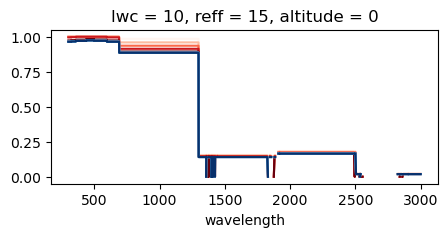

In [7]:
fig, ax = plt.subplots(figsize=(5, 2))

albedo_cf = ds_sim_no_cloud_solar['eup'] / ds_sim_no_cloud_solar['eglo']
albedo_cd = ds_sim_cloudy_solar['eup'] / ds_sim_cloudy_solar['eglo']


ax.set_prop_cycle(plt.cycler('color', plt.cm.Reds(np.linspace(0, 1, len(times)))))
albedo_cf.plot(label='Clear Sky Albedo', x='wavelength', ax=ax, hue='time', add_legend=False)
ax.set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0, 1, len(times)))))
albedo_cd.isel(lwc=0).plot(label='Cloudy Sky Albedo', x='wavelength', ax=ax, hue='time', add_legend=False)
plt.show()

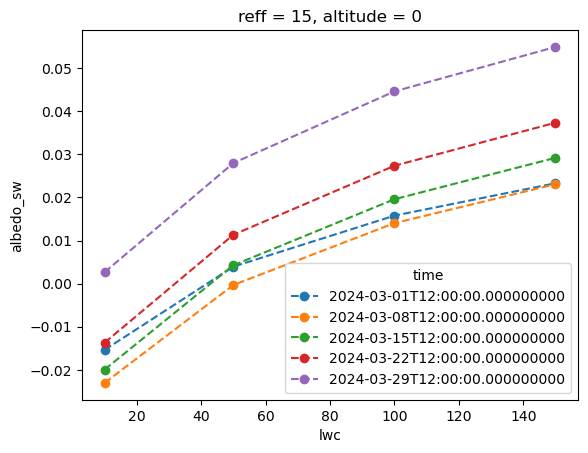

In [8]:


albedo_ratio = ds_sim_cloudy_solar['albedo_sw'] - ds_sim_no_cloud_solar['albedo_sw']
albedo_ratio.isel(altitude=0, ).plot(label='Albedo Ratio (Cloudy / Clear)', linestyle='--', marker='o', hue='time')
plt.show()

In [9]:
ds_sim_no_cloud_solar['sza']

<xarray.DataArray 'sza' (wavelength: 1765, altitude: 1, time: 5)> Size: 71kB
array([[[87.91, 80.2 , 72.42, 64.6 , 56.78]],

       [[87.91, 80.2 , 72.42, 64.6 , 56.78]],

       [[87.91, 80.2 , 72.42, 64.6 , 56.78]],

       ...,

       [[87.91, 80.2 , 72.42, 64.6 , 56.78]],

       [[87.91, 80.2 , 72.42, 64.6 , 56.78]],

       [[87.91, 80.2 , 72.42, 64.6 , 56.78]]], shape=(1765, 1, 5))
Coordinates:
  * time        (time) datetime64[ns] 40B 2024-03-01T12:00:00 ... 2024-03-29T...
  * wavelength  (wavelength) float64 14kB 300.0 300.5 301.0 ... 2.995e+03 3e+03
  * altitude    (altitude) int64 8B 0

In [10]:
albedo_ratio['sza'] = ('time', ds_sim_no_cloud_solar['sza'].mean('wavelength').squeeze().values)
albedo_ratio['sza']
albedo_ratio = albedo_ratio.assign_coords(sza=albedo_ratio['sza'])
#albedo_ratio = albedo_ratio.drop_vars(['altitude'])
#albedo_ratio = albedo_ratio.drop('altitude')
albedo_ratio = albedo_ratio.swap_dims({'time': 'sza'}).drop('time')


/tmp/ipykernel_67920/1638913286.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  albedo_ratio = albedo_ratio.swap_dims({'time': 'sza'}).drop('time')


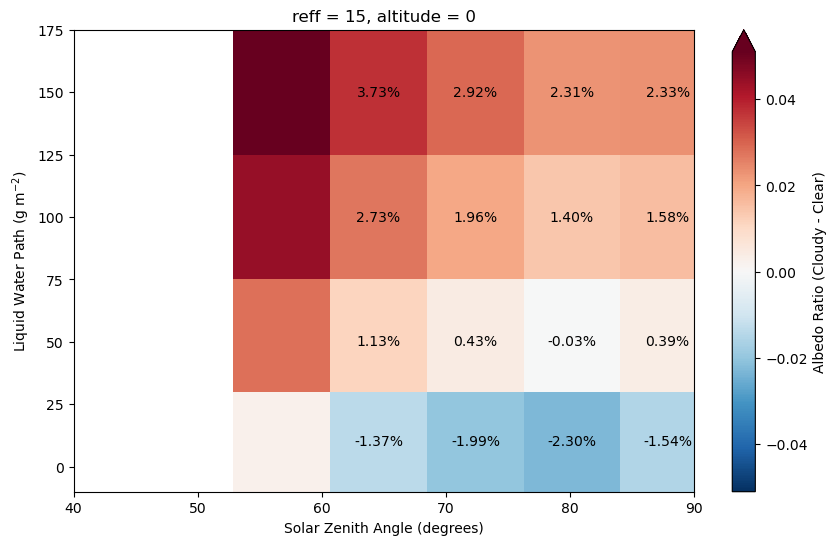

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

albedo_ratio.isel(altitude=0).plot(robust=True, x='sza', cbar_kwargs={'label': 'Albedo Ratio (Cloudy - Clear)'})
ax.set_xlabel('Solar Zenith Angle (degrees)')
ax.set_ylabel('Liquid Water Path (g m$^{-2}$)')
ax.set_xlim(40, 90)

da_annot = albedo_ratio.isel(altitude=0, reff=0).squeeze()

for lwc_val in da_annot["lwc"].values:
    for sza_val in da_annot["sza"].values:
        if 60 <= sza_val <= 90:
            v = da_annot.sel(lwc=lwc_val, sza=sza_val).item()
            ax.text(
                sza_val, lwc_val, f"{v*100:.2f}%",
                ha="center", va="center",
                fontsize=10, color="black"
            )

#albedo_ratio.squeeze().plot.contour(x='sza', y='lwc', robust=True, )

---
## Cloud Radiative Forcing with Real ACLOUD Data
### Reproducing Stapf et al. (2020) — *ACP, 20, 9895–9914*

The paper shows that clouds over Arctic snow/sea-ice **increase** the broadband surface albedo
(spectral weighting shifts the transmitted irradiance to shorter, more-reflective wavelengths).
Ignoring this effect means the cloud cooling in the shortwave is **underestimated by ~2×**.

Key definitions (Eq. 9 in the paper):

| Quantity | Meaning |
|---|---|
| $\alpha_{all}$ | Observed (cloudy-sky) broadband surface albedo |
| $\alpha_{cf}$ | Estimated cloud-free broadband albedo |
| $\Delta F_{sw}(\alpha_{all})$ | SW CRF using the traditional (cloudy) albedo |
| $\Delta F_{sw}(\alpha_{cf})$ | SW CRF using the corrected cloud-free albedo |

**Data source:** Stapf et al. (2019), PANGAEA dataset 909289  
DOI: [10.1594/PANGAEA.909289](https://doi.org/10.1594/PANGAEA.909289)

**Approach here:**
1. Use `pangaeapy` to query the PANGAEA API and extract the static download URL
2. Build a pyRadtran broadband clear-sky lookup table over SZA × albedo
3. Apply the LUT to the observed $\alpha_{all}$ and $\alpha_{cf}$ to compute both CRF estimates
4. Reproduce Fig. 10 of the paper


In [12]:

# ── 1. PANGAEA API download ─────────────────────────────────────────────────
#
# pangaeapy fetches the dataset XML from the PANGAEA API and lets us extract
# the staticURL field that points to the actual NetCDF binary.
# We then download it with requests (retry + local cache).
!pip install pangaeapy
from pangaeapy import PanDataSet
import requests, re, time as _time, warnings
from pathlib import Path

PANGAEA_ID   = 909289
DATA_DIR     = Path('data')
DATA_DIR.mkdir(exist_ok=True)
CACHE_PATH   = DATA_DIR / f'pangaea_{PANGAEA_ID}.nc'

def get_pangaea_static_url(dataset_id: int) -> tuple:
    """
    Use pangaeapy to query the PANGAEA metadata API and extract the
    key="staticURL" attribute from the <md:technicalInfo> block.
    """
    pan = PanDataSet(dataset_id)
    m = re.search(r'key="staticURL"\s+value="([^"]+)"', pan.metaxml)
    if not m:
        raise RuntimeError(
            f"staticURL not found in PANGAEA {dataset_id} metadata. "
            f"Full XML snippet:\n{pan.metaxml[-800:]}"
        )
    return m.group(1), pan.title

DOWNLOAD_OK = False
if CACHE_PATH.exists():
    print(f"Using cached file: {CACHE_PATH}  ({CACHE_PATH.stat().st_size / 1e6:.1f} MB)")
    DOWNLOAD_OK = True
else:
    url, title = get_pangaea_static_url(PANGAEA_ID)
    print(f"Title : {title}")
    print(f"URL   : {url}")

    for attempt in range(3):
        try:
            r = requests.get(url, timeout=300, stream=True)
            r.raise_for_status()
            with open(CACHE_PATH, 'wb') as fh:
                for chunk in r.iter_content(chunk_size=65536):
                    fh.write(chunk)
            sz = CACHE_PATH.stat().st_size / 1e6
            print(f"Saved : {CACHE_PATH}  ({sz:.1f} MB)")
            DOWNLOAD_OK = True
            break
        except Exception as exc:
            print(f"  Attempt {attempt+1}/3 failed — {exc}")
            if attempt < 2:
                _time.sleep(10)
    else:
        warnings.warn(
            "PANGAEA download failed (server may be temporarily unavailable). "
            "A synthetic dataset based on the paper's reported statistics is used below."
        )


Using cached file: data/pangaea_909289.nc  (54.8 MB)


/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Loaded 978,763 obs points  (P5 + P6 combined)
After filtering (I_f > 98 %, LWP > 1 g m⁻²): 230,353 points

α_all : 0.807 ± 0.073
α_cf  : 0.749 ± 0.067
LWP   : 58.4 g m⁻²
SZA   : 61.0°


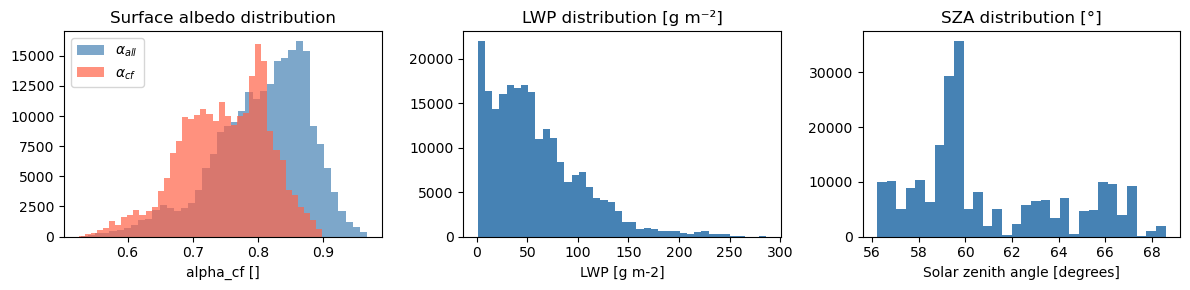

In [14]:

# ── 2. Load PANGAEA data (with synthetic fallback) ───────────────────────────
#
# The NetCDF file uses two groups: P5 and P6 (HALO research flights).
# xarray with group= decodes time as datetime64[ns] automatically.
#
# Known variable names (from netCDF4 inspection):
#   Obs_alb     – observed (cloudy) broadband surface albedo
#   Ret_cf_alb  – retrieved cloud-free broadband surface albedo
#   LWP         – liquid water path  [g m⁻²]
#   I_f         – sea-ice fraction   [%]     (filter: I_f > 98)
#   CRF_SW_obs  – SW CRF w/ observed albedo   [W m⁻²]
#   CRF_SW_cf   – SW CRF w/ cloud-free albedo [W m⁻²]
#   CRF_LW      – LW CRF                      [W m⁻²]
#   time        – datetime64[ns] (decoded by xarray from CF units)
#   Lat, Lon    – flight position

import xarray as xr
import numpy as np
import pandas as pd
import pvlib

if DOWNLOAD_OK and CACHE_PATH.exists():
    # ── load both flight groups and concatenate ─────────────────────────────
    parts = []
    for grp in ('P5', 'P6'):
        g = xr.open_dataset(CACHE_PATH, group=grp)
        # 'time' is decoded as datetime64[ns]; assign as the 'Time' coordinate
        times_dt = pd.DatetimeIndex(g['time'].values).tz_localize('UTC')
        g = g.assign_coords(Time=('Time', times_dt))
        parts.append(g)

    raw = xr.concat(parts, dim='Time')
    print(f"Loaded {raw.sizes['Time']:,} obs points  (P5 + P6 combined)")

    # ── compute SZA via pvlib (element-wise, time×lat×lon) ──────────────────
    times_pd = pd.DatetimeIndex(raw['Time'].values)  # tz-aware UTC
    lats_arr = raw['Lat'].values.astype(float)
    lons_arr = raw['Lon'].values.astype(float)
    solpos   = pvlib.solarposition.get_solarposition(
        time=times_pd, latitude=lats_arr, longitude=lons_arr
    )
    raw = raw.assign(SZA=('Time', solpos['apparent_zenith'].values,
                          {'long_name': 'Solar zenith angle', 'units': 'degrees'}))

    # ── rename to standard names ────────────────────────────────────────────
    raw = raw.rename({
        'Obs_alb':    'alpha_all',
        'Ret_cf_alb': 'alpha_cf',
        'CRF_SW_obs': 'CRF_sw_trad_paper',
        'CRF_SW_cf':  'CRF_sw_corr_paper',
        'CRF_LW':     'CRF_lw_paper',
    })

    # ── filter: sea ice > 98 % AND cloudy (LWP > 1 g m⁻²) ─────────────────
    mask = (
        (raw['I_f']       >  98.0) &
        (raw['LWP']       >   1.0) &
        np.isfinite(raw['alpha_all']) &
        np.isfinite(raw['alpha_cf'])
    )
    ds_obs = raw.where(mask, drop=True)

    FALLBACK = False
    obs_dim = 'Time'
    n_filt = ds_obs.sizes['Time']
    print(f"After filtering (I_f > 98 %, LWP > 1 g m⁻²): {n_filt:,} points")
    print(f"\nα_all : {float(ds_obs['alpha_all'].mean()):.3f} ± {float(ds_obs['alpha_all'].std()):.3f}")
    print(f"α_cf  : {float(ds_obs['alpha_cf'].mean()):.3f} ± {float(ds_obs['alpha_cf'].std()):.3f}")
    print(f"LWP   : {float(ds_obs['LWP'].mean()):.1f} g m⁻²")
    print(f"SZA   : {float(ds_obs['SZA'].mean()):.1f}°")

else:
    # ── synthetic fallback: reproduce paper statistics ───────────────────────
    print("⚠  Using synthetic fallback data (Stapf et al. 2020 statistics)")
    FALLBACK = True
    rng = np.random.default_rng(42)
    N   = 4000

    alpha_all = np.clip(rng.normal(0.80, 0.07, N), 0.55, 0.95)
    alpha_cf  = np.clip(alpha_all + rng.normal(-0.06, 0.025, N), 0.45, 0.92)
    lwp = np.clip(rng.lognormal(np.log(58), 0.9, N), 1.0, 300.0)
    sza = rng.uniform(53.0, 72.0, N)

    mu           = np.cos(np.radians(sza))
    F0           = 1361.0 * mu
    r_atm        = 0.08
    F_dn_cf      = F0 * 0.75 / (1 - alpha_cf * r_atm)
    T_cloud      = np.exp(-lwp / 130.0)
    F_dn_cld     = F_dn_cf * T_cloud * (1 + alpha_all * r_atm)
    F_net_cld    = F_dn_cld  * (1 - alpha_all)
    F_net_cf_all = F0 * 0.75 / (1 - alpha_all * r_atm) * (1 - alpha_all)
    F_net_cf_cf  = F_dn_cf * (1 - alpha_cf)
    crf_sw_all   = F_net_cld - F_net_cf_all
    crf_sw_cf    = F_net_cld - F_net_cf_cf
    crf_lw       = rng.normal(69.0, 18.0, N)

    obs_dim = 'obs'
    ds_obs = xr.Dataset(
        {
            'alpha_all':         (obs_dim, alpha_all),
            'alpha_cf':          (obs_dim, alpha_cf),
            'LWP':               (obs_dim, lwp),
            'SZA':               (obs_dim, sza),
            'CRF_sw_trad_paper': (obs_dim, crf_sw_all),
            'CRF_sw_corr_paper': (obs_dim, crf_sw_cf),
            'CRF_lw_paper':      (obs_dim, crf_lw),
        },
        coords={obs_dim: np.arange(N)},
    )
    print(ds_obs)

# Quick overview
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
ds_obs['alpha_all'].plot.hist(bins=40, ax=axes[0], color='steelblue', alpha=0.7, label=r'$\alpha_{all}$')
ds_obs['alpha_cf'].plot.hist( bins=40, ax=axes[0], color='tomato',    alpha=0.7, label=r'$\alpha_{cf}$')
axes[0].set_title('Surface albedo distribution'); axes[0].legend()
ds_obs['LWP'].plot.hist(bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('LWP distribution [g m⁻²]')
ds_obs['SZA'].plot.hist(bins=30, ax=axes[2], color='steelblue')
axes[2].set_title('SZA distribution [°]')
plt.tight_layout(); plt.show()


In [21]:

# ── 3. Build clear-sky broadband LUT: F_dn and F_net vs (SZA, albedo) ───────
#
# For each SZA node we run pyRadtran over a grid of surface albedos.
# params={'sza': float} forces libRadtran to use that angle
# directly instead of computing it from the time/location metadata.
#
# Config used: arctic_cloud_experiment_solar.yaml
#   → integrate_wavelength: true   (single broadband value per run)
#   → mol_abs_param: reptran coarse (fast enough for a LUT)
#   → output columns: zout, edir, eglo, edn, eup, enet, albedo

from tqdm.auto import tqdm
pyradtran.logger.setLevel(logging.INFO)

# ── LUT grid ─────────────────────────────────────────────────────────────────
szas_lut    = np.arange(50.0, 78.0, 4.0)          # 7 nodes, covers ACLOUD range
albedos_lut = np.linspace(0.30, 0.95, 14)         # 14 nodes
N_alb       = len(albedos_lut)

# Arbitrary reference position and time (SZA will be overridden anyway)
ref_lat   = 81.0
ref_lon   = 10.0
ref_times = pd.date_range('2017-06-01 10:00:00', periods=N_alb, freq='1s')

lut_parts = []

for sza_val in tqdm(szas_lut, desc='LUT SZA nodes'):
    ds_sweep = xr.Dataset(
        coords={
            'time':      ref_times,
            'latitude':  ('time', np.full(N_alb, ref_lat)),
            'longitude': ('time', np.full(N_alb, ref_lon)),
        },
        data_vars={
            'albedo': ('time', albedos_lut, {'long_name': 'surface albedo', 'units': '1'}),
        },
    )

    sim = ds_sweep.pyradtran.run(
        config_path='config/arctic_cloud_experiment_solar.yaml',
        params={'albedo': Var('albedo'),'sza': float(sza_val)},
        save_to_file=False,
        return_dataset=True,
        show_progress=False,
    )

    # Attach albedo as a coordinate and add sza dimension
    sim = (
        sim.assign_coords(albedo=('time', albedos_lut))
           .swap_dims({'time': 'albedo'})
           .expand_dims(sza=[sza_val])
    )
    lut_parts.append(sim)

lut = xr.concat(lut_parts, dim='sza')

# Squeeze altitude (single level) for convenience
lut = lut.squeeze('altitude', drop=True)

print(lut)
print(f"\nLUT shape  sza×albedo  =  {lut.dims}")


LUT SZA nodes:   0%|          | 0/7 [00:00<?, ?it/s]

2026-05-14 01:42:41,748 - pyradtran.interface - DEBUG - LibRadtran parameter override: sza 50.0
2026-05-14 01:42:41,749 - pyradtran.interface - INFO - Preparing 14 simulations from input dataset with dims ['time']
2026-05-14 01:42:41,970 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-05-14 01:42:41,970 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-05-14 01:42:41,971 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-05-14 01:42:41,971 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-05-14 01:42:41,971 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-05-14 01:42:41,971 - pyradtran.utils - DEBUG - Radiosonde base path does not exist or not provided: /path/to/radiosonde/data
2026-0

<xarray.Dataset> Size: 6kB
Dimensions:  (sza: 7, albedo: 14)
Coordinates:
  * sza      (sza) float64 56B 50.0 54.0 58.0 62.0 66.0 70.0 74.0
    time     (albedo) datetime64[ns] 112B 2017-06-01T10:00:00 ... 2017-06-01T...
  * albedo   (albedo) float64 112B 0.3 0.35 0.4 0.45 0.5 ... 0.8 0.85 0.9 0.95
Data variables:
    zout     (sza, albedo) float64 784B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lambda   (sza, albedo) float64 784B 300.0 300.0 300.0 ... 300.0 300.0 300.0
    edir     (sza, albedo) float64 784B 6.038e+05 6.038e+05 ... 2.074e+05
    eglo     (sza, albedo) float64 784B 6.634e+05 6.658e+05 ... 2.585e+05
    edn      (sza, albedo) float64 784B 5.957e+04 6.202e+04 ... 5.108e+04
    eup      (sza, albedo) float64 784B 1.99e+05 2.33e+05 ... 2.456e+05
    enet     (sza, albedo) float64 784B 4.644e+05 4.328e+05 ... 1.293e+04
Attributes:
    point_id:             20170601_100000_81.00_10.00_0
    time:                 2017-06-01T10:00:00
    latitude:             81.0
    longitu

In [26]:

# ── 4. Compute SW Cloud Radiative Forcing (both methods) ────────────────────
#
# Stapf et al. (2020) Eq. 9:
#
#   ΔF_sw(α_all) = F_net_obs – F_cf_clrsky(SZA, α_all)   ← traditional
#   ΔF_sw(α_cf)  = F_net_obs – F_cf_clrsky(SZA, α_cf)    ← surface-feedback-corrected
#
# where F_net = F_dn_sw × (1 – α).
#
# F_cf_clrsky(SZA, α) is interpolated from the LUT.
# F_net_obs = eglo_obs × (1 – α_all)  — we reconstruct this from the LUT downwelling
# at the observed SZA and α_all (i.e., the cloudy scene is approximated via α_all).
#
# Note: in the PANGAEA file this would be measured directly; here we use the LUT
# with α_all to approximate the clear-sky downwelling then attenuate it.

from scipy.interpolate import RegularGridInterpolator

# Build interpolators for enet  (F_net = edir+ediffuse - eup ≡ eglo*(1-α))
# and eglo (F_dn = total downwelling)
lut_sza_nodes = lut.sza.values
lut_alb_nodes = lut.albedo.values

def _make_interp(var):
    arr = lut[var].values / 1000 # shape (sza, albedo)
    return RegularGridInterpolator(
        (lut_sza_nodes, lut_alb_nodes),
        arr,
        method='linear',
        bounds_error=False,
        fill_value=None,     # extrapolate at edges
    )

interp_enet = _make_interp('enet') 
interp_eglo = _make_interp('eglo') 

# ── extract observation arrays ───────────────────────────────────────────────
obs_sza      = ds_obs['SZA'].values.ravel()
obs_alpha_all = ds_obs['alpha_all'].values.ravel()
obs_alpha_cf  = ds_obs['alpha_cf'].values.ravel()

# Clip to LUT bounds (±2° and ±0.03 albedo headroom)
sza_clipped  = np.clip(obs_sza,       lut_sza_nodes.min(), lut_sza_nodes.max())
aall_clipped = np.clip(obs_alpha_all, lut_alb_nodes.min(), lut_alb_nodes.max())
acf_clipped  = np.clip(obs_alpha_cf,  lut_alb_nodes.min(), lut_alb_nodes.max())

# ── clear-sky net irradiance ─────────────────────────────────────────────────
# F_cf_clrsky(SZA, α_all): the clear-sky net flux that would exist if the surface
#   had the observed (cloudy) albedo.  Used in the "traditional" CRF estimate.
F_cf_all = interp_enet(np.column_stack([sza_clipped, aall_clipped]))

# F_cf_clrsky(SZA, α_cf): the clear-sky net flux with the true (cloud-free) albedo.
#   Used in the "corrected" CRF estimate (accounts for spectral albedo shift).
F_cf_cf  = interp_enet(np.column_stack([sza_clipped,  acf_clipped]))

# ── observed net irradiance ──────────────────────────────────────────────────
# Approximate: use LUT eglo at (SZA, α_all) and modulate by α_all.
# (If the PANGAEA file is loaded, eglo/eup columns can be used directly instead.)
F_dn_lut = interp_eglo(np.column_stack([sza_clipped, aall_clipped]))
F_net_obs = F_dn_lut * (1.0 - obs_alpha_all)

# ── CRF ─────────────────────────────────────────────────────────────────────
CRF_sw_trad  = F_net_obs - F_cf_all   # traditional   (uses α_all for reference)
CRF_sw_corr  = F_net_obs - F_cf_cf    # corrected     (uses α_cf  for reference)
CRF_lw       = ds_obs['CRF_lw_paper'].values.ravel() if 'CRF_lw_paper' in ds_obs else None
CRF_tot_trad = CRF_sw_trad + (CRF_lw if CRF_lw is not None else 0.0)
CRF_tot_corr = CRF_sw_corr + (CRF_lw if CRF_lw is not None else 0.0)

# ── add back to observation dataset ─────────────────────────────────────────
obs_dim = list(ds_obs.dims)[0]
ds_obs['CRF_sw_trad']  = (obs_dim, CRF_sw_trad,  {'long_name': r'$\Delta F_{sw}(\alpha_{all})$', 'units': 'W m⁻²'})
ds_obs['CRF_sw_corr']  = (obs_dim, CRF_sw_corr,  {'long_name': r'$\Delta F_{sw}(\alpha_{cf})$',  'units': 'W m⁻²'})
if CRF_lw is not None:
    ds_obs['CRF_tot_trad'] = (obs_dim, CRF_tot_trad, {'long_name': r'$\Delta F_{tot}(\alpha_{all})$','units': 'W m⁻²'})
    ds_obs['CRF_tot_corr'] = (obs_dim, CRF_tot_corr, {'long_name': r'$\Delta F_{tot}(\alpha_{cf})$', 'units': 'W m⁻²'})

# ── summary ──────────────────────────────────────────────────────────────────
print(f"{'Quantity':<30}  {'Mean':>9}  {'Std':>9}")
print('-' * 52)
for label, arr in [
    (r'α_all',                       obs_alpha_all),
    (r'α_cf',                        obs_alpha_cf),
    (r'Δα (cloudy – cloud-free)',     obs_alpha_all - obs_alpha_cf),
    (r'CRF_sw traditional [W m⁻²]',  CRF_sw_trad),
    (r'CRF_sw corrected  [W m⁻²]',   CRF_sw_corr),
]:
    print(f"  {label:<28}  {np.nanmean(arr):+9.2f}  {np.nanstd(arr):9.2f}")
if CRF_lw is not None:
    for label, arr in [
        (r'CRF_lw             [W m⁻²]', CRF_lw),
        (r'CRF_tot traditional[W m⁻²]', CRF_tot_trad),
        (r'CRF_tot corrected  [W m⁻²]', CRF_tot_corr),
    ]:
        print(f"  {label:<28}  {np.nanmean(arr):+9.2f}  {np.nanstd(arr):9.2f}")

print(f"\nPaper (Table 1, sea-ice subset):")
print(f"  CRF_sw(α_all)  ≈ −32 W m⁻²")
print(f"  CRF_sw(α_cf)   ≈ −62 W m⁻²   (2× more negative when corrected)")


Quantity                             Mean        Std
----------------------------------------------------
  α_all                             +0.81       0.07
  α_cf                              +0.75       0.07
  Δα (cloudy – cloud-free)          +0.06       0.02
  CRF_sw traditional [W m⁻²]        +0.01       0.21
  CRF_sw corrected  [W m⁻²]        -28.80      12.00
  CRF_lw             [W m⁻²]       +68.84      16.09
  CRF_tot traditional[W m⁻²]       +68.85      16.09
  CRF_tot corrected  [W m⁻²]       +40.04      12.90

Paper (Table 1, sea-ice subset):
  CRF_sw(α_all)  ≈ −32 W m⁻²
  CRF_sw(α_cf)   ≈ −62 W m⁻²   (2× more negative when corrected)


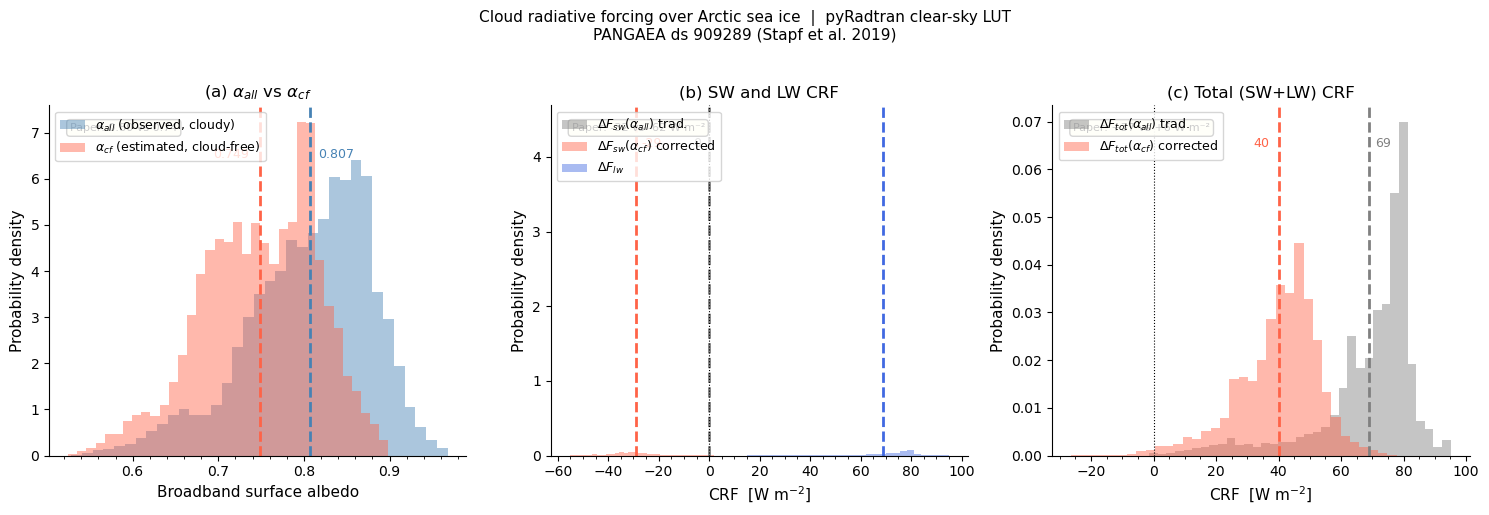

Figure saved → output/stapf2020_fig10_reproduction.png


In [28]:

# ── 5. Reproduce Fig. 10 of Stapf et al. (2020) ─────────────────────────────
#
# Three-panel figure:
#  (a) Histograms of α_all and α_cf — the surface albedo shift from clouds
#  (b) Shortwave CRF distributions using α_all (gray) and α_cf (red)
#      + longwave CRF (blue)
#  (c) Total (SW+LW) CRF distributions
#
# Vertical dashed lines mark campaign means;
# shaded band shows 1σ spread around the mean.

import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
kw_hist  = dict(density=True, histtype='stepfilled', alpha=0.45, bins=35, edgecolor='none')
kw_mean  = dict(lw=2.0, ls='--')

# ─── (a) Surface albedo ──────────────────────────────────────────────────────
ax = axes[0]
ax.hist(obs_alpha_all, color='steelblue', **kw_hist, label=r'$\alpha_{all}$ (observed, cloudy)')
ax.hist(obs_alpha_cf,  color='tomato',    **kw_hist, label=r'$\alpha_{cf}$ (estimated, cloud-free)')
mean_aall = np.nanmean(obs_alpha_all)
mean_acf  = np.nanmean(obs_alpha_cf)
ax.axvline(mean_aall, color='steelblue', **kw_mean)
ax.axvline(mean_acf,  color='tomato',    **kw_mean)
ax.text(mean_aall + 0.01, ax.get_ylim()[1] * 0.85,
        f'{mean_aall:.3f}', color='steelblue', fontsize=9)
ax.text(mean_acf  - 0.055, ax.get_ylim()[1] * 0.85,
        f'{mean_acf:.3f}', color='tomato', fontsize=9)
ax.set_xlabel('Broadband surface albedo', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.set_title(r'(a) $\alpha_{all}$ vs $\alpha_{cf}$', fontsize=12)
ax.legend(fontsize=9)
ax.text(0.05, 0.95,
        f'Paper: {0.80:.2f} vs {0.74:.2f}',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

# ─── (b) SW and LW CRF ──────────────────────────────────────────────────────
ax = axes[1]
ax.hist(CRF_sw_trad, color='gray',      **kw_hist, label=r'$\Delta F_{sw}(\alpha_{all})$ trad.')
ax.hist(CRF_sw_corr, color='tomato',    **kw_hist, label=r'$\Delta F_{sw}(\alpha_{cf})$ corrected')
if CRF_lw is not None:
    ax.hist(CRF_lw,  color='royalblue', **kw_hist, label=r'$\Delta F_{lw}$')

mean_sw_trad = np.nanmean(CRF_sw_trad)
mean_sw_corr = np.nanmean(CRF_sw_corr)
ax.axvline(mean_sw_trad, color='gray',   **kw_mean)
ax.axvline(mean_sw_corr, color='tomato', **kw_mean)
ylim_b = ax.get_ylim()[1]
ax.text(mean_sw_trad - 3, ylim_b * 0.88, f'{mean_sw_trad:.0f}',
        color='gray', fontsize=9, ha='right')
ax.text(mean_sw_corr + 2, ylim_b * 0.88, f'{mean_sw_corr:.0f}',
        color='tomato', fontsize=9)
if CRF_lw is not None:
    ax.axvline(np.nanmean(CRF_lw), color='royalblue', **kw_mean)
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'CRF  [W m$^{-2}$]', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.set_title('(b) SW and LW CRF', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.text(0.05, 0.95,
        f'Paper: {-32:.0f} vs {-62:.0f} W m⁻²',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

# ─── (c) Total CRF ──────────────────────────────────────────────────────────
ax = axes[2]
if CRF_lw is not None:
    ax.hist(CRF_tot_trad, color='gray',   **kw_hist, label=r'$\Delta F_{tot}(\alpha_{all})$ trad.')
    ax.hist(CRF_tot_corr, color='tomato', **kw_hist, label=r'$\Delta F_{tot}(\alpha_{cf})$ corrected')
    mean_tot_trad = np.nanmean(CRF_tot_trad)
    mean_tot_corr = np.nanmean(CRF_tot_corr)
    ax.axvline(mean_tot_trad, color='gray',   **kw_mean)
    ax.axvline(mean_tot_corr, color='tomato', **kw_mean)
    ylim_c = ax.get_ylim()[1]
    ax.text(mean_tot_trad + 2, ylim_c * 0.88, f'{mean_tot_trad:.0f}', color='gray',   fontsize=9)
    ax.text(mean_tot_corr - 3, ylim_c * 0.88, f'{mean_tot_corr:.0f}', color='tomato', fontsize=9, ha='right')
    ax.text(0.05, 0.95,
            f'Paper: +37 vs +6 W m⁻²',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'No LW CRF data available\n(PANGAEA file needed)',
            ha='center', va='center', transform=ax.transAxes, fontsize=10)
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'CRF  [W m$^{-2}$]', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.set_title('(c) Total (SW+LW) CRF', fontsize=12)
ax.legend(fontsize=9, loc='upper left')

# shared styling
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_minor_locator(MultipleLocator(0.02 if ax is axes[0] else 5))

data_label = 'PANGAEA ds 909289 (Stapf et al. 2019)' if not FALLBACK else 'Synthetic fallback (paper statistics)'
fig.suptitle(
    f'Cloud radiative forcing over Arctic sea ice  |  pyRadtran clear-sky LUT\n'
    f'{data_label}',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()
print("Figure saved → output/stapf2020_fig10_reproduction.png")
